<a href="https://colab.research.google.com/github/gisele-mgs/especializacacin/blob/main/Atividade_Nao_Supervisionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Análise do comportamento de compra dos consumidores do Pernambuco a partir do RFM - Olist Dataset**

##Grupo:
* Giovanna Bloise de Almeida
* Maria Gisele Macedo Silva
* Vitor Polanski Barros de Araújo

Essa métrica foi escolhida, tendo como referência uma análise publicada no kaggle, para poder entender o comportamento de compras através do RFM.

RFM: Recency, Frequency and Monetary

1. Quão recente foi a última compra?
2. Com que frequência o cliente comprou em um período?
3. Quanto dinheiro o cliente gastou no total?

Através disso, espera-se traçar o perfil de compras

# 1. Importação da base de dados via kaggle:

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/brazilian-ecommerce


In [ ]:
!ls  /root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2

ls: cannot access '/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2': No such file or directory


# Referências utilizadas


* https://www.kaggle.com/code/leandroal/an-lise-do-e-commerce-no-brasil-olist-dataset

* https://www.kaggle.com/code/jayheewon/rfm-customer-segmentation-by-cluster-analysis

Base de dados escolhida: https://www.kaggle.com/code/leandroal/an-lise-do-e-commerce-no-brasil-olist-dataset

Base de dados da Olist -- loja de startup brasileira que atua no segmento de tecnologia para varejo --  com informações de mais de 100 mil pedidos de 2016 a 2018.


#2. Definição de variáveis de interesse

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
plt.style.use('fivethirtyeight')
from sklearn.cluster import DBSCAN
import plotly.express as px

* *Importação do dataframe via pandas e cruzamento de dados para formação de uma só base de dados*

In [ ]:
files = {'customers'    : '/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv',
         'geolocation'  : '/kaggle/input/brazilian-ecommerce/olist_geolocation_dataset.csv',
         'items'        : '/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv',
         'payment'      : '/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv',
         'orders'       : '/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv',
         'products'     : '/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv',
         'sellers'      : '/kaggle/input/brazilian-ecommerce/olist_sellers_dataset.csv',
         'review'       : '/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv',
         }

dfs = {}
for key, value in files.items():
      dfs[key] = pd.read_csv(value)

Cruzamento gradativo dos das colunas de interesse e recorte para o estado do Pernambuco:
  * Dados de pagamentos, itens do pedido, pedidos e clientes.

In [ ]:
df1 = dfs['payment'].merge(dfs['items'], on = 'order_id')
df2 = df1.merge(dfs['orders'], on = 'order_id' )
df = df2.merge(dfs['customers'], on = 'customer_id')
df = df[df['customer_state'] == 'PE']
df

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,...,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
88,110d9355d6338eab0a65a0cacdde5434,1,credit_card,5,566.40,1,acdcfb0e41f8091492386a014aa8d57d,f9eedec3129e8cc6b6429c42d0808c5b,2018-07-30 21:50:25,539.90,...,delivered,2018-07-24 21:30:17,2018-07-24 21:50:25,2018-07-25 15:35:00,2018-08-02 19:46:49,2018-08-10 00:00:00,2a6f1c54c079bb319508a8278df9febc,54250,jaboatao dos guararapes,PE
131,0b65284a1a74114ea029b7676fdc1ba3,1,credit_card,7,144.20,1,f7e0fa615b386bc9a8b9eb52bc1fff76,87142160b41353c4e5fca2360caf6f92,2017-05-15 05:02:14,89.90,...,delivered,2017-05-09 04:33:51,2017-05-09 05:02:14,2017-05-09 08:18:13,2017-06-09 17:12:16,2017-06-16 00:00:00,9202421110f6a19ddcf0b9b93602a0a1,55500,escada,PE
144,8f936fb77c720ab9ccd618af38c885cc,1,credit_card,4,46.63,1,9c7ce59c96e74dfdfc51f13a4a6c3869,6560211a19b47992c3666cc44a7e94c0,2017-09-13 09:35:20,29.00,...,delivered,2017-09-06 09:24:02,2017-09-06 09:35:20,2017-09-06 17:21:38,2017-09-17 14:25:56,2017-10-02 00:00:00,35a4f22fd08c2cf0007129a2ff4e0546,50070,recife,PE
179,18259631aab7299bf25f83f5eac4c8d1,1,credit_card,4,220.30,1,966123de13ad29f76b83d5f9752405f5,bd697db56ff8e7c9cd1abeb7f72029b2,2018-07-12 17:35:25,199.99,...,delivered,2018-07-10 17:22:37,2018-07-10 20:31:35,2018-07-11 16:08:00,2018-07-20 19:54:55,2018-07-31 00:00:00,729d3aa65c34acf0f35811a707adfefe,52030,recife,PE
253,3fff175860497ca456d60c90b1f2b797,1,credit_card,2,168.57,1,08a58dc963320d6073623382b9ceb920,8e8a7ce9f2f970dc00e2acf6f6e199f6,2018-05-14 22:15:24,129.00,...,delivered,2018-05-09 22:06:27,2018-05-09 22:15:24,2018-05-11 14:06:00,2018-06-04 16:24:31,2018-06-05 00:00:00,d7702658d570da430a6f4f9c4719d7ca,56720,itapetim,PE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117157,21446a89bd1b60e7daab9013a9b1f6de,1,boleto,1,55.62,1,3b0f7951038b105522c2d566b54421f7,562fc2f2c2863ab7e79a9e4388a58a14,2018-03-08 02:10:37,29.99,...,delivered,2018-02-28 19:40:09,2018-03-02 02:10:37,2018-03-07 23:35:16,2018-04-19 21:16:58,2018-03-29 00:00:00,280f4052479455e2975918c0f9bb6dcc,55813,carpina,PE
117190,5dfb8335958a3157a733c424ba959ced,1,credit_card,7,399.22,1,2f178dc91b792930e1ff40a77a123506,75d34ebb1bd0bd7dde40dd507b8169c3,2018-02-01 08:29:51,379.99,...,delivered,2018-01-24 21:48:46,2018-01-26 08:29:51,2018-01-29 22:32:46,2018-02-06 17:54:40,2018-02-19 00:00:00,ad03c627bccad43903347f9c90aa4000,52081,recife,PE
117202,90087834f1b051b9e44f4fdbe2aebd8a,1,credit_card,3,174.28,1,a9ae3095ce9466944a7427933de5f784,293dee954235e4e4e43f129313625ebe,2018-01-11 20:31:43,137.99,...,delivered,2018-01-04 20:10:54,2018-01-04 20:32:23,2018-01-05 21:33:07,2018-01-19 02:19:13,2018-02-08 00:00:00,eb6b70852bfeca1cd91b3105a840ba32,55330,bom conselho,PE
117248,1a6b1c532300b42629e52ada22f26ccf,1,credit_card,2,68.94,1,1ec486885049bbb9b79351d150ed18c4,cab85505710c7cb9b720bceb52b01cee,2018-03-29 16:15:32,49.90,...,delivered,2018-03-25 16:05:53,2018-03-25 16:15:32,2018-03-26 18:47:42,2018-04-03 16:37:42,2018-04-19 00:00:00,14477dd0d95124aaf3b0cbd2d31b5dc6,50610,recife,PE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1889 entries, 88 to 117294
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       1889 non-null   object 
 1   payment_sequential             1889 non-null   int64  
 2   payment_type                   1889 non-null   object 
 3   payment_installments           1889 non-null   int64  
 4   payment_value                  1889 non-null   float64
 5   order_item_id                  1889 non-null   int64  
 6   product_id                     1889 non-null   object 
 7   seller_id                      1889 non-null   object 
 8   shipping_limit_date            1889 non-null   object 
 9   price                          1889 non-null   float64
 10  freight_value                  1889 non-null   float64
 11  customer_id                    1889 non-null   object 
 12  order_status                   1889 non-null   obj

##Recência

- Métrica que indica quanto tempo se passou desde última compra


In [ ]:
# Separando um novo df de recencia
df_user = pd.DataFrame(df ['customer_unique_id'])
df_user.columns = ['customer_unique_id'] #df de id's de usuários

# Agrupa os dados pelo ID único do cliente e pega a data mais recente de compra (última compra)
df_max_purchase = df.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
df_max_purchase.rename(columns = {'order_purchase_timestamp' :'maxPurchaseDate'}, inplace = True)

# Obtendo as compras mais recentes
df_max_purchase['maxPurchaseDate'] = pd.to_datetime(df_max_purchase['maxPurchaseDate'])
# Calcula o valor de quantos dias fazem a ultima compra de cada cliente
df_max_purchase['recencia'] = (df_max_purchase['maxPurchaseDate'].max() - df_max_purchase['maxPurchaseDate']).dt.days
df_user = pd.merge(df_user, df_max_purchase[['customer_unique_id','recencia']], on ='customer_unique_id')
df_user.recencia.describe()

,recencia
count,1889.000000
mean,234.460032
std,150.033473
min,0.000000
25%,110.000000
50%,219.000000
75%,346.000000
max,687.000000


# Frequência

In [ ]:
df_frequencia =df.groupby('customer_unique_id').order_purchase_timestamp.count().reset_index()
df_frequencia.rename (columns = {'order_purchase_timestamp' :'frequencia'}, inplace = True)

df_user = pd.merge(df_user, df_frequencia, on='customer_unique_id')
df_user.frequencia.describe()

,frequencia
count,1889.000000
mean,1.524087
std,1.404283
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,12.000000


# Valor total gasto por usuário

In [ ]:
df_valor_total = df.groupby('customer_unique_id')['payment_value'].sum().reset_index()
df_valor_total.rename(columns={'payment_value': 'valor_total'}, inplace=True)
df_user = pd.merge(df_user, df_valor_total, on='customer_unique_id')
df_user

,customer_unique_id,recencia,frequencia,valor_total
0,2a6f1c54c079bb319508a8278df9febc,29,1,566.40
1,9202421110f6a19ddcf0b9b93602a0a1,470,1,144.20
2,35a4f22fd08c2cf0007129a2ff4e0546,350,1,46.63
3,729d3aa65c34acf0f35811a707adfefe,43,1,220.30
4,d7702658d570da430a6f4f9c4719d7ca,105,1,168.57
...,...,...,...,...
1884,280f4052479455e2975918c0f9bb6dcc,175,1,55.62
1885,ad03c627bccad43903347f9c90aa4000,210,1,399.22
1886,eb6b70852bfeca1cd91b3105a840ba32,230,1,174.28
1887,14477dd0d95124aaf3b0cbd2d31b5dc6,150,1,68.94


# Análise Descritiva

In [ ]:
# Define as condições
condicoes = [
    (df_user['frequencia'] > 4) & (df_user['valor_total'] > 1000),         # Top Clientes
    (df_user['recencia'] >= 90),                                      # Risco de Abandono
    (df_user['recencia'] < 90) & (df_user['frequencia'] < 3),        # Clientes Novos
    (df_user['frequencia'] < 3),                                   # Ocasionais
]

# Define os rótulos na ordem de prioridade
rotulos = [
    'Top Clientes',
    'Clientes em Risco de Abandono',
    'Clientes Novos',
    'Clientes Ocasionais',
]

# Aplica as condições
df_user['segmento_cliente'] = np.select(condicoes, rotulos, default='Outros')

print(df_user['segmento_cliente'].value_counts())



segmento_cliente
Clientes em Risco de Abandono    1496
Clientes Novos                    346
Top Clientes                       28
Outros                             19
Name: count, dtype: int64


In [ ]:
desc_stats = df_user.groupby('segmento_cliente')[['recencia', 'frequencia', 'valor_total']].agg({
    'recencia': ['mean', 'median', 'min', 'max'],
    'frequencia': ['mean', 'median', 'min', 'max'],
    'valor_total': ['mean', 'median', 'sum', 'count']
}).round(2)

print(desc_stats)

                              recencia                 frequencia             \
                                  mean median min  max       mean median min   
segmento_cliente                                                               
Clientes Novos                   41.59   38.0   0   88       1.15    1.0   1   
Clientes em Risco de Abandono   284.03  269.5  90  687       1.42    1.0   1   
Outros                           49.95   70.0  13   83       3.21    3.0   3   
Top Clientes                     94.61   82.0   0  333      10.36   11.0   5   

                                  valor_total                            
                              max        mean   median        sum count  
segmento_cliente                                                         
Clientes Novos                  2      244.26   167.72   84514.69   346  
Clientes em Risco de Abandono   6      291.59   143.08  436213.11  1496  
Outros                          4      883.83   575.04   16792.68    

In [ ]:
import plotly.express as px

# Crie o histograma com escala logarítmica no eixo y
fig = px.histogram(df_user,
                   x='valor_total',
                   nbins=50,
                   title='Distribuição do Valor Total Gasto por Usuário (Escala Logarítmica)',
                   labels={'valor_total': 'Valor Total (R$)'},
                   color_discrete_sequence=['#636EFA'],
                   log_y=True)  # Escala logarítmica no eixo y

# Ajustes adicionais no layout
fig.update_layout(
    bargap=0.1,
    xaxis_title="Valor Total (R$)",
    yaxis_title="Contagem (log scale)",
    showlegend=False,
    plot_bgcolor='white',
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        range=[0, 4000]  # Limite o eixo x para focar na região principal
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray'
    )
)

# Adicionar uma linha vertical para destacar a média ou mediana, se desejar
# mean_val = df_user['valor_total'].mean()
# fig.add_vline(x=mean_val, line_width=2, line_dash="dash", line_color="red")

fig.show()

In [ ]:

fig = px.scatter_3d(
    df_user,
    x='recencia',
    y='frequencia',
    z='valor_total',
    color='segmento_cliente',
    title="<b>Clusters de Usuários RFM (3D)</b><br><sup>Segmentação por Recência, Frequência e Valor Monetário</sup>",
    opacity=0.8,
    size_max=10,  # Controla o tamanho máximo dos pontos
    height=700,  # Altura do gráfico
    labels={
        'recencia': 'Recência (dias)',
        'frequencia': 'Frequência (compras)',
        'valor_total': 'Valor Total (R$)',
        'segmento_cliente': 'Segmento do Cliente'
    },
    color_discrete_sequence=px.colors.qualitative.Vivid,  # Paleta de cores mais vibrante
    symbol='segmento_cliente'  # Diferentes símbolos para cada segmento (opcional)
)

# Ajustes adicionais de layout
fig.update_layout(
    legend=dict(
        title='Segmento',
        orientation="h",  # Legenda horizontal
        yanchor="bottom",
        y=-0.2,  # Posição abaixo do gráfico
        xanchor="center",
        x=0.5
    ),
    scene=dict(
        xaxis=dict(title='<b>Recência</b> (dias)'),
        yaxis=dict(title='<b>Frequência</b> (compras)'),
        zaxis=dict(title='<b>Valor Monetário</b> (R$)'),
        camera=dict(  # Ajuste da perspectiva inicial
            eye=dict(x=1.5, y=1.5, z=0.5)
        )
    ),
    margin=dict(l=0, r=0, b=80, t=100),  # Margens ajustadas
    title_x=0.5  # Título centralizado
)

fig.update_traces(
    hovertemplate=(
        "<b>Segmento: %{marker.symbol}</b><br><br>"
        "Recência: %{x} dias<br>"
        "Frequência: %{y} compras<br>"
        "Valor Total: R$ %{z:,.2f}<br>"
        "Cliente ID: %{customdata[0]}<extra></extra>"
    ),
    customdata=df_user[['customer_unique_id']].values
)


fig.show()

O **ticket médio** é um indicador muito importante para avaliar o desempenho das suas vendas e é resultante da média das vendas. Para fazer o cálculo, é só dividir o faturamento total das vendas pelo número de vendas do intervalo de tempo em questão.

Fazer a mensuração do faturamento mensal **contribui para a tomada de decisões e permite orientar os investimentos e as ações internas**, por isso o ticket médio é considerado uma métrica fundamental para o planejamento financeiro de um estabelecimento.


https://sebrae.com.br/sites/PortalSebrae/artigos/o-que-e-ticket-medio,5d4a00d232766810VgnVCM1000001b00320aRCRD#:~:text=O%20ticket%20m%C3%A9dio%20%C3%A9%20um,intervalo%20de%20tempo%20em%20quest%C3%A3o.

<ipython-input-130-3789800221>:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




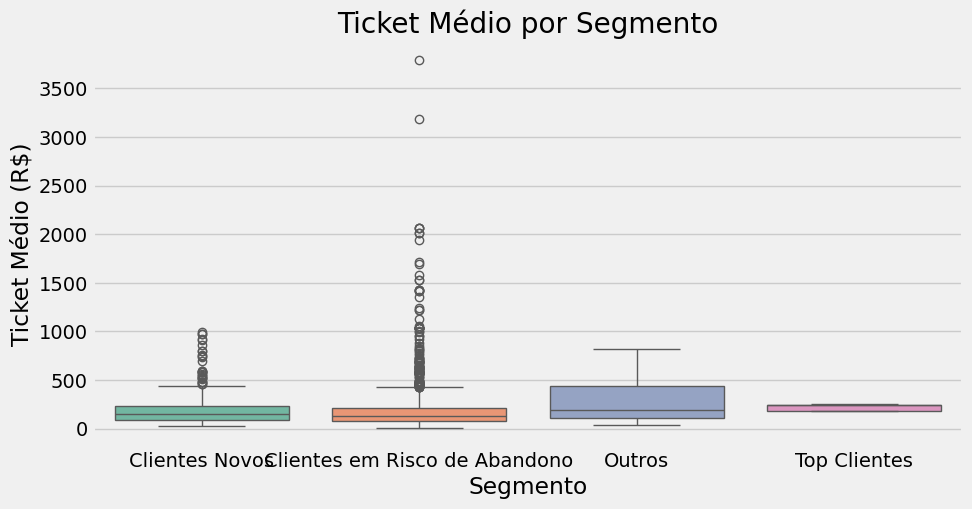

In [ ]:
df_user['ticket_medio'] = df_user['valor_total'] / df_user['frequencia']
df_user['tempo_medio_entre_compras'] = df_user['recencia'] / df_user['frequencia']
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_user, x='segmento_cliente', y='ticket_medio', palette='Set2')
plt.title('Ticket Médio por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Ticket Médio (R$)')
plt.show()


In [ ]:
!pip install streamlit

In [ ]:
def normalize(column):
    return (column - column.min()) / (column.max() - column.min())

df_user_norm = df_user.copy()
df_user_norm['recencia_norm'] = 1 - normalize(df_user['recencia'])  # Inverter recência (quanto maior, pior
df_user_norm['frequencia_norm'] = normalize(df_user['frequencia'])
df_user_norm['valor_total_norm'] = normalize(df_user['valor_total'])

df_melted = df_user_norm.melt(
    id_vars='segmento_cliente',
    value_vars=['recencia_norm', 'frequencia_norm', 'valor_total_norm'],
    var_name='metric',
    value_name='value'
)

# Mapear nomes das métricas
metric_labels = {
    'recencia_norm': 'Recência (1-R)',
    'frequencia_norm': 'Frequência',
    'valor_total_norm': 'Valor Monetário'
}
df_melted['metric'] = df_melted['metric'].map(metric_labels)



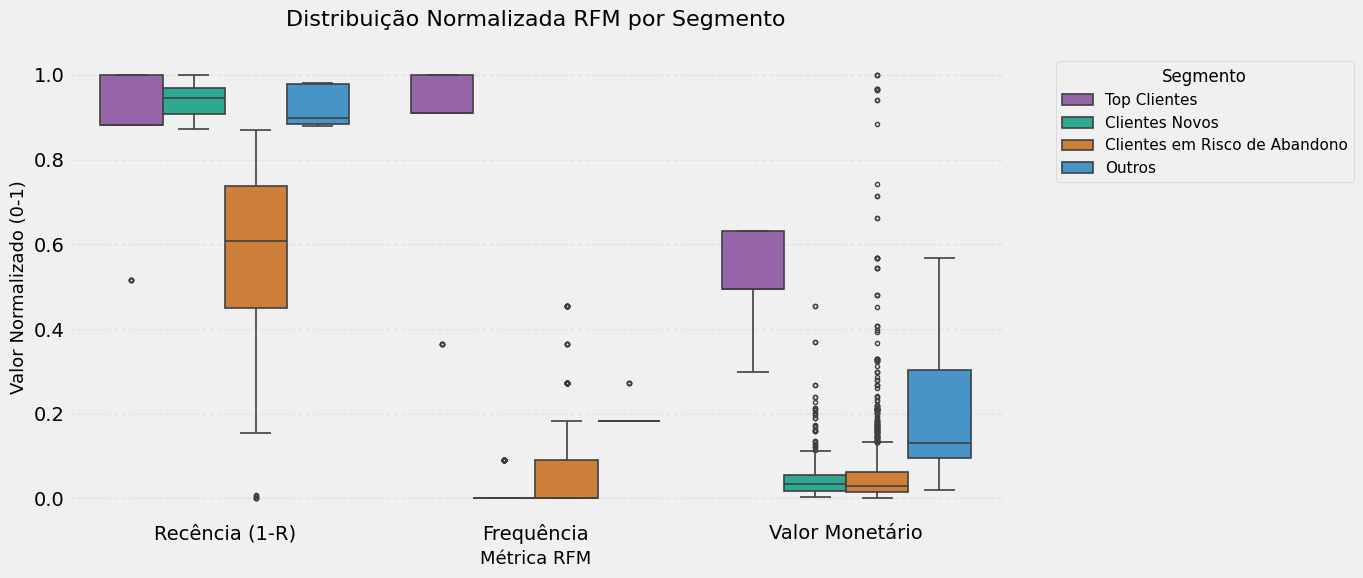

In [ ]:


plt.figure(figsize=(14, 6))

palette = {
    'Top Clientes': '#9b59b6',               # Roxo
    'Clientes Novos': '#1abc9c',             # Verde água
    'Clientes em Risco de Abandono': '#e67e22',  # Laranja
    'Outros': '#3498db'                      # Azul
}

hue_order = ['Top Clientes', 'Clientes Novos', 'Clientes em Risco de Abandono', 'Outros']

sns.boxplot(
    data=df_melted,
    x='metric',
    y='value',
    hue='segmento_cliente',
    palette=palette,
    hue_order=hue_order,
    linewidth=1.2,
    fliersize=3
)

plt.title('Distribuição Normalizada RFM por Segmento', fontsize=16, pad=20)
plt.xlabel('Métrica RFM', fontsize=13)
plt.ylabel('Valor Normalizado (0-1)', fontsize=13)

# Legenda fora do gráfico
plt.legend(title='Segmento', bbox_to_anchor=(1.05, 1), fontsize=11, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()


| Segmento                          | Recência (1-R) | Frequência | Valor Monetário | Perfil Resumido                               |
| --------------------------------- | -------------- | ---------- | --------------- | --------------------------------------------- |
| **Top Clientes**                  | Alta           | Alta       | Alta            | Fieis, compram muito e recentemente           |
| **Clientes Novos**                | Alta           | Baixa      | Baixa           | Compraram só uma vez e gastaram pouco         |
| **Clientes em Risco de Abandono** | Média-baixa    | Baixa      | Baixa           | Compraram no passado, mas estão inativos      |
| **Outros**                        | Alta           | Baixa      | Média/Alta      | Alguns têm potencial, mas ainda não são fieis |


In [ ]:

# Agrupar e somar valores por cidade
df_city_spend = df.groupby('customer_city')['price'].sum().reset_index()

# Top 10 cidades que mais gastaram
top_cities_spend = df_city_spend.sort_values('price', ascending=False).head(10)

# Adicionar texto formatado em reais (pt-BR)
top_cities_spend['price_formatted'] = top_cities_spend['price'].apply(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'v').replace('.', ',').replace('v', '.')
)

# Criar coluna de cores para destacar Recife
top_cities_spend['bar_color'] = top_cities_spend['customer_city'].apply(
    lambda x: 'gold' if x == 'recife' else 'indigo'
)

# Ordenar para garantir o gráfico correto
top_cities_spend = top_cities_spend.sort_values('price', ascending=True)

# Criar gráfico
fig = px.bar(
    top_cities_spend,
    x='price',
    y='customer_city',
    orientation='h',
    color='bar_color',
    color_discrete_map={
        'gold': '#FFD700',
        'indigo': '#4B0082'
    },
    text='price_formatted',
    title='<b>Top 10 Cidades que Mais Gastaram</b><br><span style="font-size:12px">Valores acumulados em compras</span>',
    labels={'price': 'Valor Total (R$)', 'customer_city': 'Cidade'},
    width=1000,
    height=600
)

# Layout aprimorado
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_x=0.5,
    title_y=0.95,
    font=dict(family="Arial", size=12),
    xaxis=dict(
        title='<b>Valor Total Gasto (R$)</b>',
        gridcolor='lightgray',
        showgrid=True,
        tickformat=",.2f"
    ),
    yaxis=dict(
        title='<b>Cidade</b>',
        tickfont=dict(size=12)
    ),
    coloraxis_showscale=False,
    margin=dict(l=100, r=50, b=80, t=100)
)

# Melhorar visual das barras
fig.update_traces(
    marker_line_color='black',
    marker_line_width=1,
    textposition='outside',
    textfont_size=12,
    hovertemplate="<b>%{y}</b><br>Total Gasto: %{text}<extra></extra>"
)

# Linha de média
mean_value = top_cities_spend['price'].mean()
fig.add_vline(
    x=mean_value,
    line_dash="dot",
    line_color="red",
    line_width=2,
    annotation_text=f"Média: R$ {mean_value:,.2f}".replace(',', 'v').replace('.', ',').replace('v', '.'),
    annotation_position="bottom right",
    annotation_font_size=12,
    annotation_font_color="red"
)

# Anotação para Recife
fig.add_annotation(
    x=top_cities_spend['price'].max(),
    y='recife',
    text='Cidade com maior gasto',
    showarrow=True,
    arrowhead=2,
    ax=100,
    ay=0,
    font=dict(color="black", size=12)
)

fig.show()


<ipython-input-135-60835630>:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




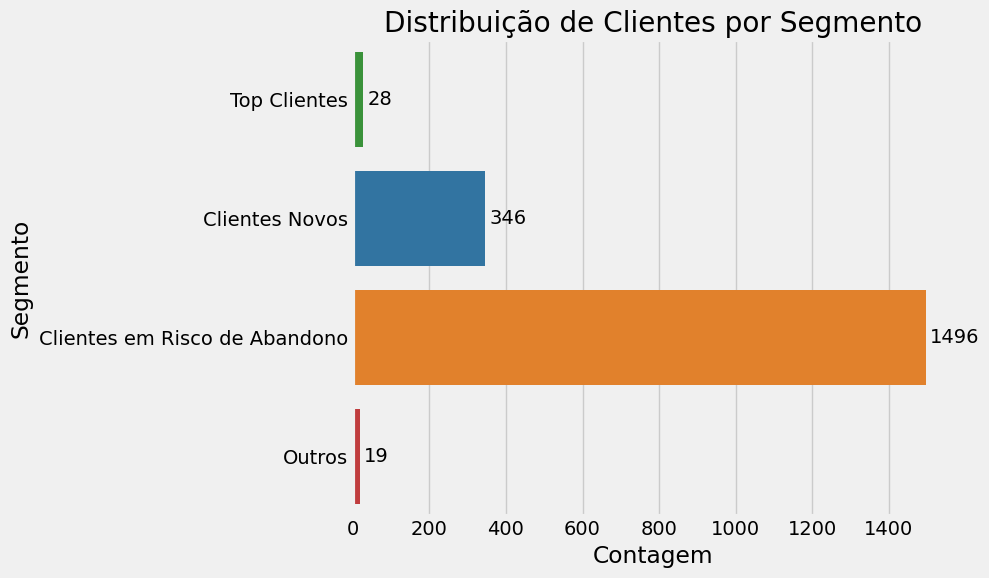

In [ ]:
# Definindo ordem personalizada dos segmentos
ordem_personalizada = ['Top Clientes', 'Clientes Novos', 'Clientes em Risco de Abandono', 'Outros']

# Paleta de cores personalizada (ajustável conforme o gosto)
cores_personalizadas = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']  # verde, azul, laranja, vermelho

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df_user,
    y='segmento_cliente',
    order=ordem_personalizada,
    palette=cores_personalizadas
)

plt.title('Distribuição de Clientes por Segmento')
plt.xlabel('Contagem')
plt.ylabel('Segmento')

# Adicionando rótulos com as contagens nas barras
for p in ax.patches:
    count = int(p.get_width())
    ax.text(
        p.get_width() + 10,                          # deslocamento horizontal
        p.get_y() + p.get_height() / 2,              # posição vertical central
        count,                                       # valor exibido
        va='center'
    )

plt.tight_layout()
plt.show()


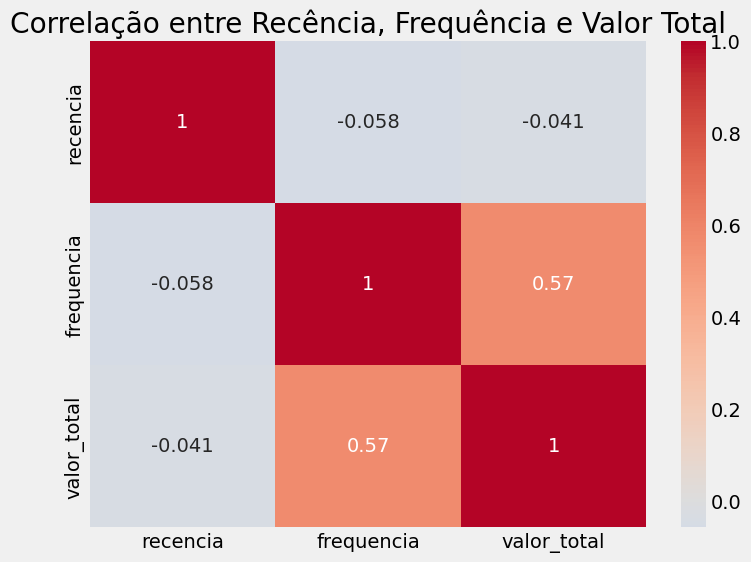

In [ ]:
# Matriz de correlação
corr = df_user[['recencia', 'frequencia', 'valor_total']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlação entre Recência, Frequência e Valor Total')
plt.show()

1. Frequência vs. Recência (0.57)

  * Correlação positiva moderada: Clientes que compram com mais frequência também tendem a ter compras mais recentes.



2. Valor Total vs. Frequência (-0.058)

  * Quase nenhuma correlação: O valor gasto não está linearmente relacionado à frequência de compras.


3. Valor Total vs. Recência (-0.041)

  * Correlação negativa muito fraca: Clientes que gastam mais levemente tendem a ser um pouco mais recentes, mas a relação é quase irrelevante.

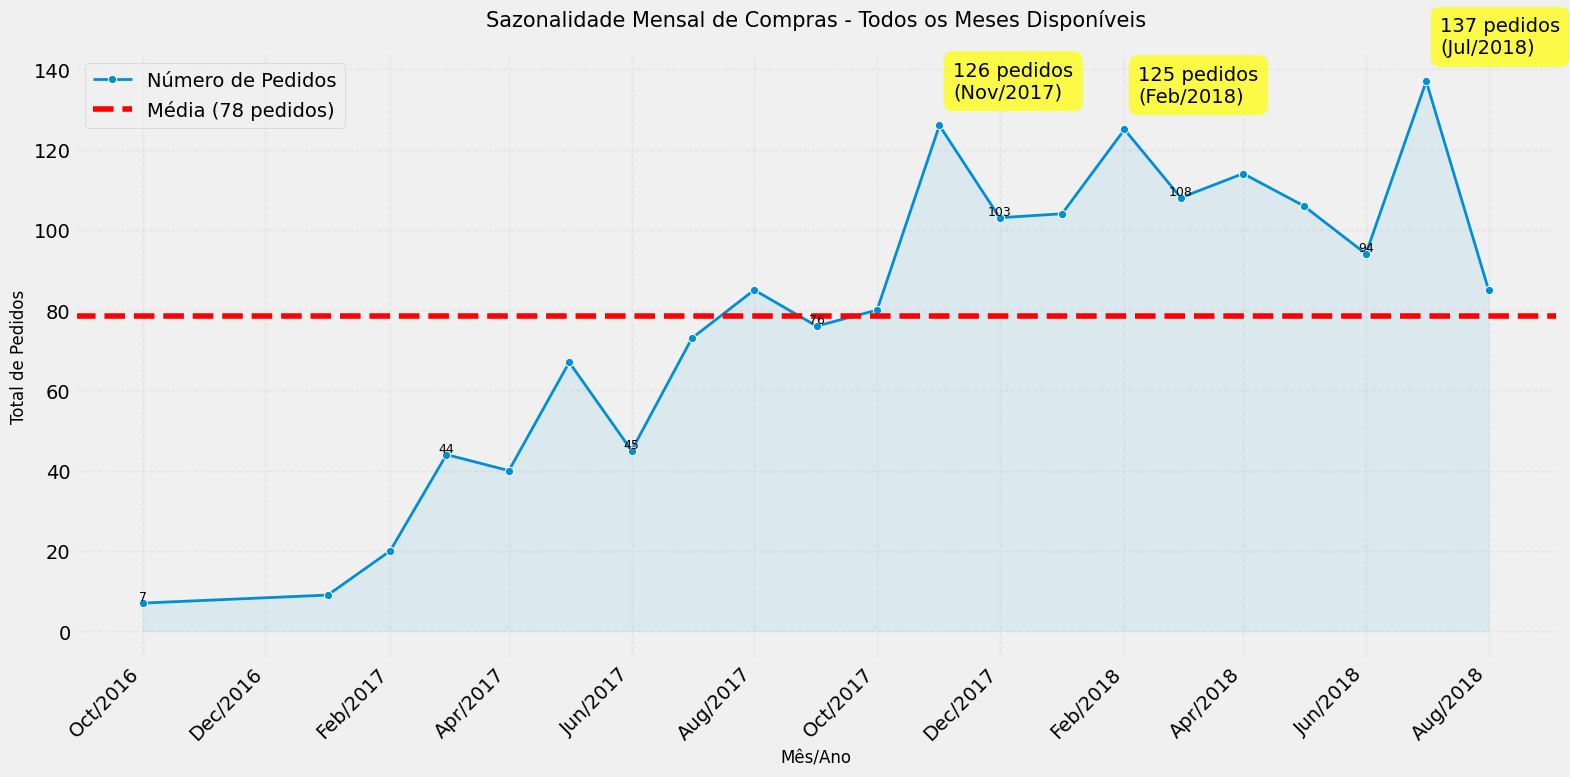


Meses ordenados por volume de pedidos:
   mes_ano  order_id
2018-07-01       137
2017-11-01       126
2018-02-01       125
2018-04-01       114
2018-03-01       108
2018-05-01       106
2018-01-01       104
2017-12-01       103
2018-06-01        94
2018-08-01        85
2017-08-01        85
2017-10-01        80
2017-09-01        76
2017-07-01        73
2017-05-01        67
2017-06-01        45
2017-03-01        44
2017-04-01        40
2017-02-01        20
2017-01-01         9
2016-10-01         7


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento dos dados temporais
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['mes_ano'] = df['order_purchase_timestamp'].dt.to_period('M')

# Agregação por mês com todos os dados disponíveis
compras_mensais = df.groupby('mes_ano').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()
compras_mensais['mes_ano'] = compras_mensais['mes_ano'].dt.to_timestamp()

# Ordenar por data para garantir a sequência correta
compras_mensais = compras_mensais.sort_values('mes_ano')

# Identificar os 3 meses com maior número de pedidos
top_meses = compras_mensais.nlargest(3, 'order_id')
media_pedidos = compras_mensais['order_id'].mean()

# Configuração do gráfico
plt.figure(figsize=(16, 8))
ax = sns.lineplot(data=compras_mensais, x='mes_ano', y='order_id',
                 marker='o', linewidth=2, label='Número de Pedidos')

# Preenchimento da área sob a curva
plt.fill_between(compras_mensais['mes_ano'], compras_mensais['order_id'],
                 alpha=0.2, color='skyblue')

# Adicionar valores dos top meses
for i, row in top_meses.iterrows():
    ax.annotate(f"{row['order_id']} pedidos\n({row['mes_ano'].strftime('%b/%Y')})",
                xy=(row['mes_ano'], row['order_id']),
                xytext=(10, 20), textcoords='offset points',
                arrowprops=dict(arrowstyle='->'),
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7))

# Linha de média
plt.axhline(media_pedidos, color='red', linestyle='--',
            label=f'Média ({media_pedidos:.0f} pedidos)')

# Personalização do gráfico
plt.title('Sazonalidade Mensal de Compras - Todos os Meses Disponíveis', pad=20, fontsize=15)
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Total de Pedidos', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Melhorar formatação das datas no eixo X
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))

# Adicionar grid para facilitar leitura
plt.grid(True, linestyle='--', alpha=0.3)

# Adicionar valores em cada ponto
for i, row in compras_mensais.iterrows():
    if i % 3 == 0:  # Mostrar apenas alguns valores para não poluir
        ax.text(row['mes_ano'], row['order_id'], f"{row['order_id']:.0f}",
                ha='center', va='bottom', fontsize=9)

sns.despine()
plt.legend()
plt.tight_layout()
plt.show()

# Mostrar tabela com os meses ordenados por volume
print("\nMeses ordenados por volume de pedidos:")
print(compras_mensais[['mes_ano', 'order_id']].sort_values('order_id', ascending=False).to_string(index=False))

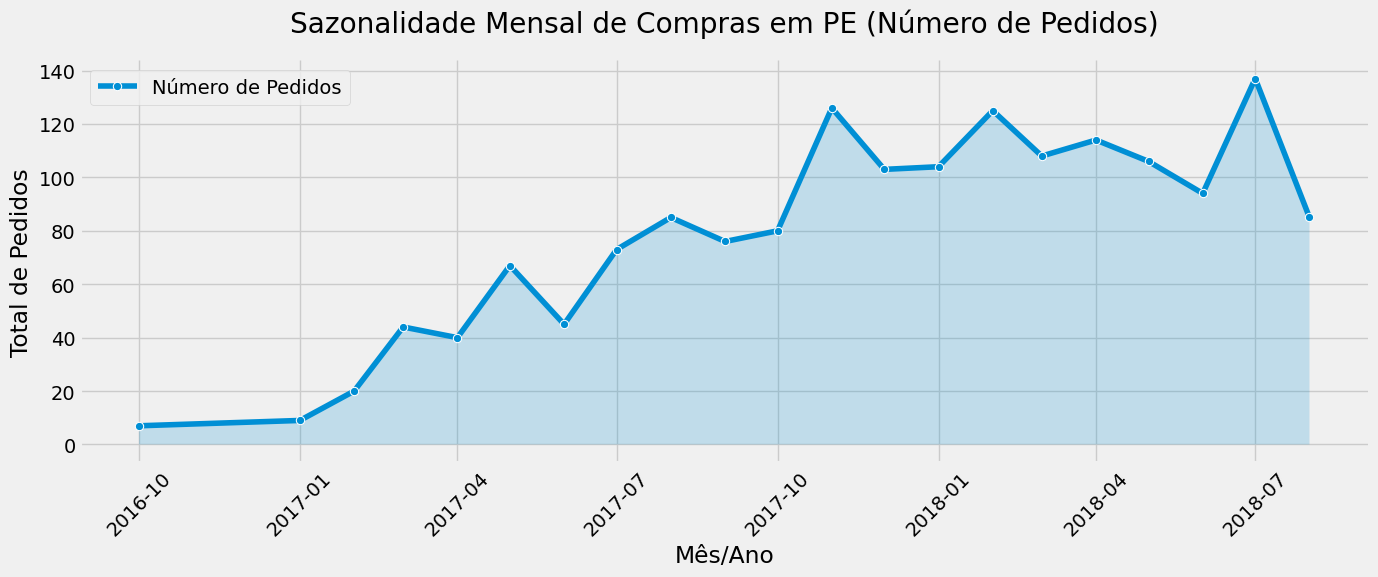

In [ ]:
# Pré-processamento dos dados temporais
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['mes_ano'] = df['order_purchase_timestamp'].dt.to_period('M')
df['trimestre_ano'] = df['order_purchase_timestamp'].dt.to_period('Q')

# Agregação por mês
compras_mensais = df.groupby('mes_ano').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()
compras_mensais['mes_ano'] = compras_mensais['mes_ano'].dt.to_timestamp()

# Agregação por trimestre
compras_trimestrais = df.groupby('trimestre_ano').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()
compras_trimestrais['trimestre_ano'] = compras_trimestrais['trimestre_ano'].dt.to_timestamp()

# Gráfico de sazonalidade mensal (com linhas de tendência)
plt.figure(figsize=(14, 6))
sns.lineplot(data=compras_mensais, x='mes_ano', y='order_id',
             marker='o', label='Número de Pedidos')
plt.fill_between(compras_mensais['mes_ano'], compras_mensais['order_id'],
                 alpha=0.2)
plt.title('Sazonalidade Mensal de Compras em PE (Número de Pedidos)', pad=20)
plt.xlabel('Mês/Ano')
plt.ylabel('Total de Pedidos')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()


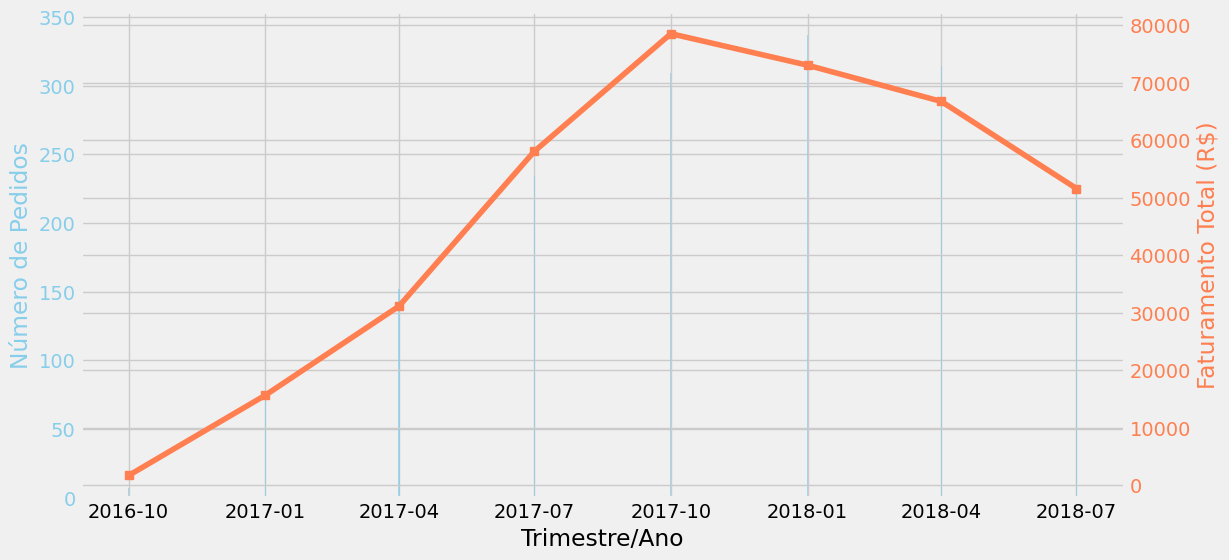

In [ ]:

# Gráfico combinado trimestral (Barras + Linha)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para número de pedidos
ax1.bar(compras_trimestrais['trimestre_ano'], compras_trimestrais['order_id'],
        color='skyblue', alpha=0.7, label='Pedidos')
ax1.set_xlabel('Trimestre/Ano')
ax1.set_ylabel('Número de Pedidos', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Linha para faturamento
ax2 = ax1.twinx()
ax2.plot(compras_trimestrais['trimestre_ano'], compras_trimestrais['payment_value'],
         color='coral', marker='s', label='Faturamento (R$)')
ax2.set_ylabel('Faturamento Total (R$)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

## AP 03

Algoritmos de clusterização



# Hierárquico

In [ ]:
from sklearn.cluster import AgglomerativeClustering


In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


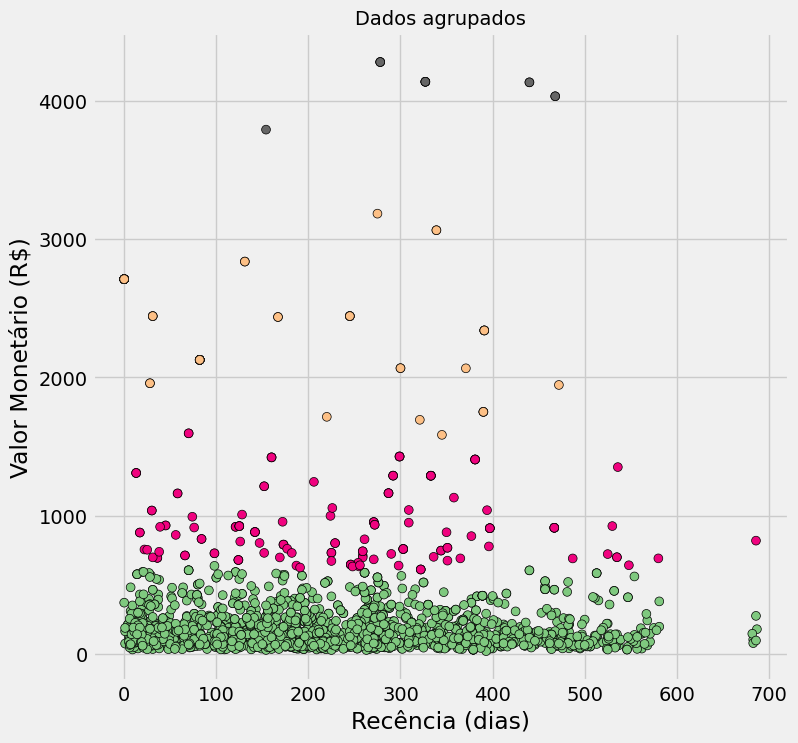

In [ ]:
X = df_user[['recencia', 'frequencia', 'valor_total']]

# Agrupamento hierárquico
clustering = AgglomerativeClustering(n_clusters=4, linkage='ward').fit(X)

# Plotagem dos clusters
plt.figure(figsize=(8, 8))
plt.title("Dados agrupados", fontsize="medium")
plt.xlabel("Recência (dias)")
plt.ylabel("Valor Monetário (R$)")

# Scatter plot com melhorias
plt.scatter(
    X['recencia'],
    X['valor_total'],
    c=clustering.labels_,
    cmap='Accent',      # Melhor colormap
    s=40,             # Tamanho maior dos pontos
    marker='o',       # Marcador circular
    edgecolor='k'     # Borda preta
)

plt.show()

In [ ]:
# Dados originais (não normalizados) para visualização
df_hier = X.copy()

# Normalização para clustering
scaler = StandardScaler()
X_scaled_hier = scaler.fit_transform(df_hier)

# Agrupamento hierárquico
clustering = AgglomerativeClustering(n_clusters=4, linkage='ward').fit(X_scaled_hier)

# Atribui rótulo do cluster aos dados originais
df_hier['cluster'] = clustering.labels_

color_sequence = px.colors.qualitative.Bold  # Alternativas: Set2, Dark2, Pastel

fig = px.scatter_3d(
    df_hier,
    x='recencia',
    y='frequencia',
    z='valor_total',
    color='cluster',
    color_discrete_sequence=color_sequence,
    title="Clusters de usuários de PE (3D) - Agrupamento Hierárquico",
    opacity=0.7,
    hover_data=['recencia', 'frequencia', 'valor_total']
)

fig.show()

In [ ]:
!pip install -U kaleido

In [ ]:
#fig.write_image("cluster_3d.png", width=900, height=800)


# KMeans

In [ ]:
from sklearn.cluster import KMeans


# Copia dos dados
df_kmeans = X.copy()


scaler = StandardScaler()
X_scaled_k = scaler.fit_transform(df_kmeans)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled_k)

# Adiciona os rótulos ao DataFrame original
df_kmeans['customer_unique_id_k'] = kmeans.labels_


# Gráfico 3D com as variáveis originais (não normalizadas)
fig = px.scatter_3d(
    df_kmeans,
    x='recencia',
    y='frequencia',
    z='valor_total',
    color='customer_unique_id_k',
    title="Clusters de usuários de PE (3D) KMeans",
    opacity=0.7
)
fig.show()




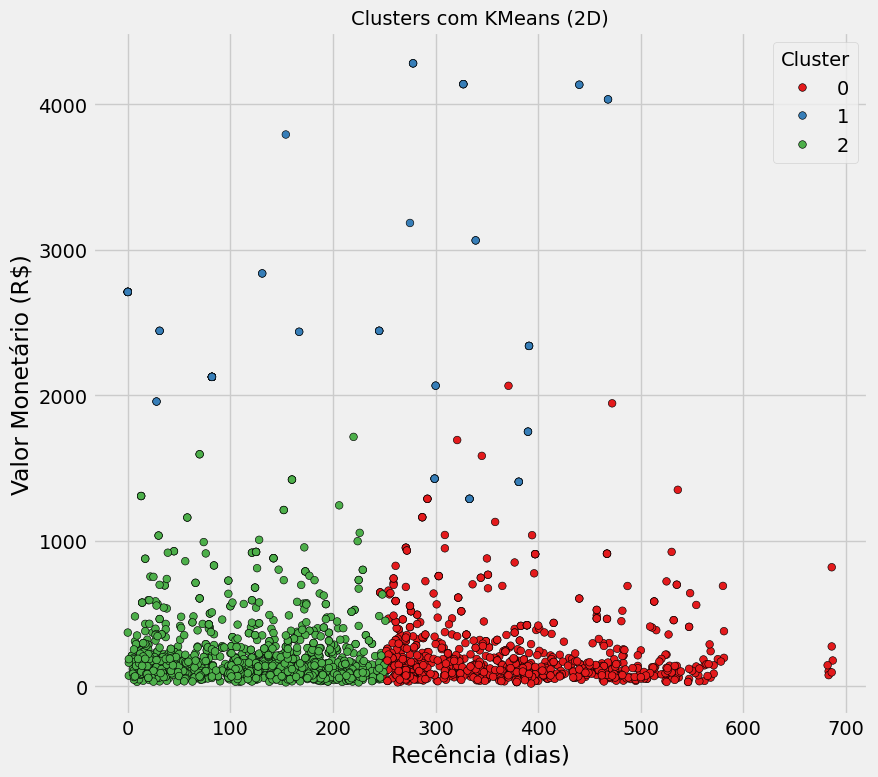

In [ ]:
df_kmeans['cluster'] = kmeans.labels_

palette = sns.color_palette("Set1", n_colors=3)

plt.figure(figsize=(9, 8))
plt.title("Clusters com KMeans (2D)", fontsize=14)
sns.scatterplot(
    data=df_kmeans,
    x='recencia',
    y='valor_total',
    hue='cluster',
    palette=palette,
    s=30,
    edgecolor='k'
)
plt.xlabel("Recência (dias)")
plt.ylabel("Valor Monetário (R$)")
plt.legend(title="Cluster", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# DBScan

In [ ]:
from sklearn.cluster import DBSCAN

epsilon = 1.4
min_samples = 13

df_dbscan = X.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_dbscan)

db = DBSCAN(eps=epsilon, min_samples=min_samples).fit(X_scaled)
df_dbscan['customer_unique_id_db'] = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(df_dbscan['customer_unique_id_db'])) - (1 if -1 in df_dbscan['customer_unique_id_db'] else 0)
n_noise_ = list(df_dbscan['customer_unique_id_db']).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

# Melhore sua visualização 3D
fig = px.scatter_3d(
    df_dbscan,
    x='recencia',
    y='frequencia',
    z='valor_total',
    color='customer_unique_id_db',
    title=f"Clusters DBSCAN (ε={epsilon}, min_samples={min_samples}) - {n_clusters_} clusters",
    opacity=0.7,
    hover_data=['customer_unique_id_db'],  # Adicione dados relevantes
    labels={'recencia': 'Recência (dias)', 'frequencia': 'Frequência', 'valor_total': 'Valor Total'},
    color_discrete_sequence=px.colors.qualitative.Vivid  # Melhor paleta de cores
)

# Adicione anotações
fig.update_layout(
    scene=dict(
        xaxis_title='Recência (dias)',
        yaxis_title='Frequência de Compras',
        zaxis_title='Valor Total Gasto'
    ),
    legend_title_text='Cluster'
)

fig.show()



Estimated number of clusters: 2
Estimated number of noise points: 49


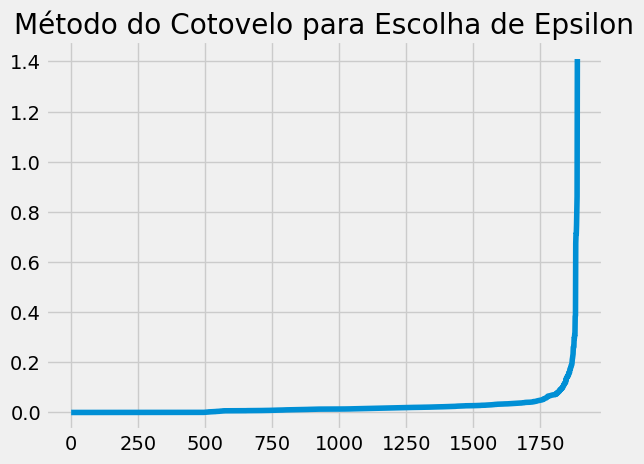

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Método do cotovelo para escolher epsilon
neigh = NearestNeighbors(n_neighbors=min_samples)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
distances = np.sort(distances, axis=0)
distances = distances[:,1]

plt.plot(distances)
plt.title('Método do Cotovelo para Escolha de Epsilon')
plt.show()

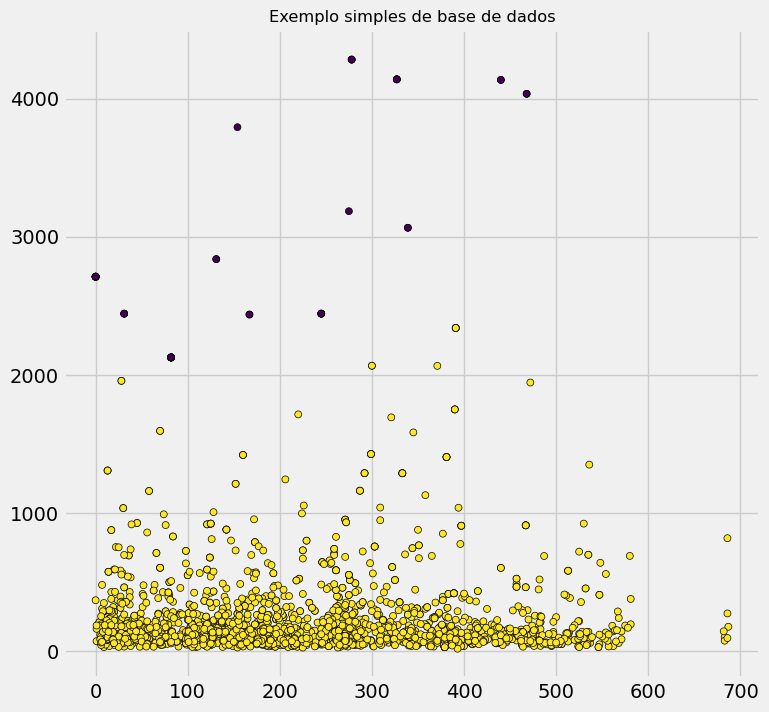

In [ ]:
plt.figure(figsize=(8, 8))
plt.title("Exemplo simples de base de dados", fontsize="small")
plt.scatter(df_dbscan['recencia'], df_dbscan['valor_total'], c = df_dbscan['customer_unique_id_db'], marker="o", s=25, edgecolor="k")
plt.show()

In [ ]:
from sklearn import metrics

# Calcular métricas
labels = db.labels_
if len(set(labels)) > 1:
    print(f"Silhouette Coefficient: {metrics.silhouette_score(X_scaled, labels):.3f}")
    print(f"Calinski-Harabasz Index: {metrics.calinski_harabasz_score(X_scaled, labels):.3f}")
else:
    print("Não é possível calcular métricas com apenas 1 cluster")

Silhouette Coefficient: 0.768
Calinski-Harabasz Index: 991.205


# SOM -Self Organzing Map

In [ ]:
%pip install sklearn-som

In [ ]:
from sklearn_som.som import SOM


In [ ]:
X = df_user[['recencia', 'frequencia', 'valor_total']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Criar e treinar o SOM 3x3
som = SOM(m=2, n=2, dim=3, random_state=42)  # Grade 3x3 para 9 clusters possíveis
som.fit(X_scaled, epochs=1000)

# 4. Atribuir clusters (0 a 8, total de 9 neurônios)
df_user['cluster_som'] = som.predict(X_scaled)


print("Distribuição de pontos por cluster (SOM 3x3):")
print(df_user['cluster_som'].value_counts().sort_index())



# 7. Visualização 3D
fig = px.scatter_3d(
    df_user,
    x='recencia',
    y='frequencia',
    z='valor_total',
    color='cluster_som',
    title="Clusters com SOM ",
    opacity=0.7,
    color_continuous_scale='viridis',
    labels={'cluster_som': 'Cluster SOM'}
)
fig.update_layout(scene=dict(
    xaxis_title='Recência',
    yaxis_title='Frequência',
    zaxis_title='Valor Total'
))
fig.show()

Distribuição de pontos por cluster (SOM 3x3):
cluster_som
0    364
1    576
2    650
3    299
Name: count, dtype: int64


# Fuzzy C Means (FCM)

In [ ]:
!pip install fuzzy-c-means


In [ ]:
X_scaled


array([[-1.36979057, -0.37330492,  0.47351502],
       [ 1.57033183, -0.37330492, -0.32890053],
       [ 0.77029852, -0.37330492, -0.51433797],
       ...,
       [-0.02973478, -0.37330492, -0.27173175],
       [-0.56309032, -0.37330492, -0.47193652],
       [ 2.08368653, -0.37330492, -0.37468498]])

In [ ]:
from fcmeans import FCM


In [ ]:

# Define the number of clusters
n_clusters = 3

# Initialize the FCM algorithm
fcm = FCM(n_clusters=n_clusters)

# Fit the data to the FCM algorithm
fcm.fit(X_scaled)

In [ ]:
# Get the cluster centers and the membership matrix
centroids = fcm.centers
membership_mat = fcm.u

In [ ]:
labels = np.argmax(membership_mat, axis=1)

labels

array([1, 2, 2, ..., 1, 1, 2])

In [ ]:


df_user['cluster_fcm'] = labels

fig = px.scatter_3d(
    df_user,
    x='recencia',
    y='frequencia',
    z='valor_total',
    color='cluster_fcm',
    title="Clusters com Fuzzy C-Means (Cluster Principal)",
    opacity=0.7,
    color_continuous_scale='viridis',
    labels={'cluster_fcm': 'Cluster FCM'}
)
fig.update_layout(scene=dict(
    xaxis_title='Recência',
    yaxis_title='Frequência',
    zaxis_title='Valor Total'
))
fig.show()

In [ ]:
# Calcula a "força" da pertinência
strength = np.sort(membership_mat, axis=1)[:, -1] - np.sort(membership_mat, axis=1)[:, -2]

df_user['pertinencia_cluster_principal'] = np.max(membership_mat, axis=1)
df_user['ambiguidade'] = 1 - strength  # Quanto maior, mais "dividido" entre clusters

fig = px.scatter_3d(
    df_user,
    x='recencia',
    y='frequencia',
    z='valor_total',
    color='pertinencia_cluster_principal',
    size='ambiguidade',
    title="Fuzzy C-Means: Grau de Pertinência ao Cluster Principal",
    opacity=0.7,
    color_continuous_scale='viridis',
    labels={
        'pertinencia_cluster_principal': 'Pertinência',
        'ambiguidade': 'Ambiguidade'
    }
)
fig.update_layout(scene=dict(
    xaxis_title='Recência',
    yaxis_title='Frequência',
    zaxis_title='Valor Total'
))
fig.show()

# AP 04

## Critérios internos

In [ ]:
from sklearn.metrics.cluster import silhouette_score
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [ ]:
def compute_gap_statistic(data, nrefs=3, max_clusters=10):
    """
    Calcula a estatística Gap para determinar o número ótimo de clusters.

    Parâmetros:
        data: dados normalizados (n_samples, n_features)
        nrefs: número de datasets de referência
        max_clusters: número máximo de clusters a testar

    Retorna:
        optimal_k: número ótimo de clusters
        gap_df: DataFrame com os resultados
    """
    gaps = np.zeros(max_clusters)
    results = []

    for k in range(1, max_clusters+1):
        # Dispersão dos dados reais
        km = KMeans(n_clusters=k, random_state=42)
        km.fit(data)
        orig_disp = km.inertia_

        # Dispersão dos dados de referência
        ref_dispersions = np.zeros(nrefs)
        for i in range(nrefs):
            random_data = np.random.random_sample(size=data.shape)
            km.fit(random_data)
            ref_dispersions[i] = km.inertia_

        # Calcula a estatística Gap
        gap = np.log(np.mean(ref_dispersions)) - np.log(orig_disp)
        gaps[k-1] = gap
        results.append({'k': k, 'gap': gap, 'ref_disp': np.mean(ref_dispersions), 'orig_disp': orig_disp})

    gap_df = pd.DataFrame(results)
    optimal_k = gap_df['gap'].idxmax() + 1  # +1 porque começa em k=1

    return optimal_k, gap_df

Número ótimo de clusters sugerido pela estatística Gap: 10


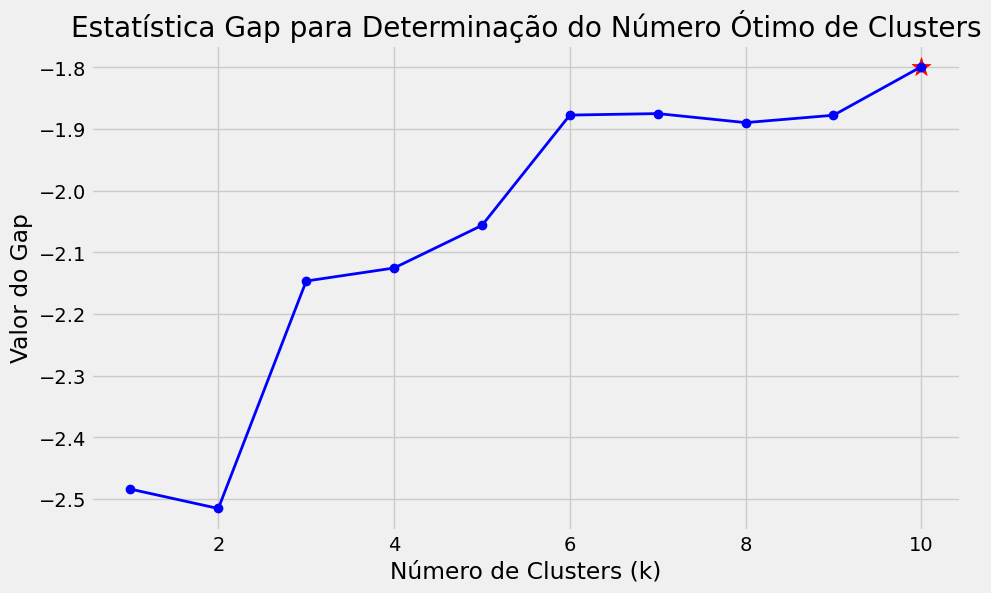

In [ ]:

scaler = StandardScaler()
X_scaled_k = scaler.fit_transform(df_kmeans[['recencia', 'frequencia', 'valor_total']])

 #Calcular o k ótimo com Gap Statistic
optimal_k, gap_df = compute_gap_statistic(X_scaled_k, nrefs=5, max_clusters=10)

print(f"Número ótimo de clusters sugerido pela estatística Gap: {optimal_k}")


plt.figure(figsize=(10, 6))
plt.plot(gap_df['k'], gap_df['gap'], 'bo-', linewidth=2)
plt.scatter(optimal_k, gap_df[gap_df['k']==optimal_k]['gap'], s=200, c='red', marker='*')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Valor do Gap')
plt.title('Estatística Gap para Determinação do Número Ótimo de Clusters')
plt.grid(True)
plt.show()


## Criterios relativos

In [ ]:
from sklearn.metrics.cluster import silhouette_score, davies_bouldin_score, calinski_harabasz_score


In [ ]:
### 1.1 Silhouette Score
"""
O Silhouette Score mede quão similar um ponto é ao seu próprio cluster comparado aos outros clusters.
Valores variam de -1 a 1, onde:
- Próximo de 1: pontos estão bem agrupados
- Próximo de 0: pontos estão na fronteira entre clusters
- Próximo de -1: pontos podem estar no cluster errado
"""

print("="*60)
print("CRITÉRIOS INTERNOS DE VALIDAÇÃO")
print("="*60)

# Dados normalizados para comparação justa
X_scaled = StandardScaler().fit_transform(X)

# 1. Silhouette Score para cada algoritmo
print("\n1. SILHOUETTE SCORE (quanto maior, melhor - range: -1 a 1)")
print("-" * 55)

# Hierarchical Clustering
silhouette_hier = silhouette_score(X_scaled, clustering.labels_)
print(f"Hierarchical Clustering: {silhouette_hier:.4f}")

# K-Means
silhouette_kmeans = silhouette_score(X_scaled, kmeans.labels_)
print(f"K-Means:                 {silhouette_kmeans:.4f}")

# DBSCAN (removendo pontos de ruído para cálculo)
mask_no_noise = db.labels_ != -1
# Check if there are enough points and more than one cluster after removing noise
if np.sum(mask_no_noise) > 1 and len(set(db.labels_[mask_no_noise])) > 1:
    silhouette_dbscan = silhouette_score(X_scaled[mask_no_noise], db.labels_[mask_no_noise])
    print(f"DBSCAN (sem ruído):      {silhouette_dbscan:.4f}")
else:
    print("DBSCAN: Não foi possível calcular (menos de 2 clusters após remover ruído)")

# Fuzzy C-Means
# FCM doesn't provide hard labels directly, but we can get representative labels
# by taking the cluster with the maximum membership probability for each point.
fcm_labels = np.argmax(fcm.u, axis=1)
if len(set(fcm_labels)) > 1: # Ensure there's more than one cluster
    silhouette_fcm = silhouette_score(X_scaled, fcm_labels)
    print(f"Fuzzy C-Means:           {silhouette_fcm:.4f}")
else:
    print("Fuzzy C-Means: Não foi possível calcular (apenas 1 cluster)")

CRITÉRIOS INTERNOS DE VALIDAÇÃO

1. SILHOUETTE SCORE (quanto maior, melhor - range: -1 a 1)
-------------------------------------------------------
Hierarchical Clustering: 0.4299
K-Means:                 0.4279
DBSCAN: Não foi possível calcular (menos de 2 clusters após remover ruído)
Fuzzy C-Means:           0.4294


In [ ]:
"""### 1.2 Davies-Bouldin Index
O Davies-Bouldin Index mede a razão entre dispersão intra-cluster e separação inter-cluster.
Valores menores indicam melhor clustering (0 é o melhor valor possível).
"""

print("\n2. DAVIES-BOULDIN INDEX (quanto menor, melhor - mínimo: 0)")
print("-" * 55)

# Davies-Bouldin Index para cada algoritmo
db_hier = davies_bouldin_score(X_scaled, clustering.labels_)
print(f"Hierarchical Clustering: {db_hier:.4f}")

db_kmeans = davies_bouldin_score(X_scaled, kmeans.labels_)
print(f"K-Means:                 {db_kmeans:.4f}")

# DBSCAN (removendo pontos de ruído)
# Check if there are enough non-noise points and at least 2 non-noise clusters
mask_no_noise = db.labels_ != -1
non_noise_labels = db.labels_[mask_no_noise]
if len(set(non_noise_labels)) > 1 and np.sum(mask_no_noise) > 1:
    db_dbscan = davies_bouldin_score(X_scaled[mask_no_noise], non_noise_labels)
    print(f"DBSCAN (sem ruído):      {db_dbscan:.4f}")
else:
    # Refined message to indicate why calculation failed
    if len(set(non_noise_labels)) <= 1:
         print("DBSCAN: Não foi possível calcular (apenas 1 ou nenhum cluster após remover ruído)")
    else:
         print("DBSCAN: Não foi possível calcular (insuficientes pontos após remover ruído)")


# Fuzzy C-Means
# Verifica se há mais de um cluster nos rótulos do FCM antes de calcular
fcm_labels = np.argmax(fcm.u, axis=1)
if len(set(fcm_labels)) > 1:
    db_fcm = davies_bouldin_score(X_scaled, fcm_labels)
    print(f"Fuzzy C-Means:           {db_fcm:.4f}")
else:
    print("Fuzzy C-Means: Não foi possível calcular (apenas 1 cluster)")


2. DAVIES-BOULDIN INDEX (quanto menor, melhor - mínimo: 0)
-------------------------------------------------------
Hierarchical Clustering: 0.8978
K-Means:                 0.8678
DBSCAN: Não foi possível calcular (apenas 1 ou nenhum cluster após remover ruído)
Fuzzy C-Means:           0.8660


In [ ]:
"""### 1.3 Calinski-Harabasz Index (Variance Ratio Criterion)
O Calinski-Harabasz Index é a razão entre dispersão inter-cluster e intra-cluster.
Valores maiores indicam clusters mais densos e bem separados.
"""

print("\n3. CALINSKI-HARABASZ INDEX (quanto maior, melhor)")
print("-" * 55)

# Calinski-Harabasz Index para cada algoritmo
ch_hier = calinski_harabasz_score(X_scaled, clustering.labels_)
print(f"Hierarchical Clustering: {ch_hier:.4f}")

ch_kmeans = calinski_harabasz_score(X_scaled, kmeans.labels_)
print(f"K-Means:                 {ch_kmeans:.4f}")

# DBSCAN (removendo pontos de ruído)
# Verificar se há mais de um cluster após remover o ruído
unique_labels_no_noise = len(set(db.labels_[mask_no_noise]))
if unique_labels_no_noise > 1 and np.sum(mask_no_noise) > 1:
    ch_dbscan = calinski_harabasz_score(X_scaled[mask_no_noise], db.labels_[mask_no_noise])
    print(f"DBSCAN (sem ruído):      {ch_dbscan:.4f}")
else:
    # Informar o motivo pelo qual o cálculo não foi possível
    if unique_labels_no_noise <= 1:
         print("DBSCAN: Não foi possível calcular (apenas 1 ou nenhum cluster após remover ruído)")
    else:
         print("DBSCAN: Não foi possível calcular (insuficientes pontos após remover ruído)")


# Fuzzy C-Means
# Verifica se há mais de um cluster nos rótulos do FCM antes de calcular
fcm_labels = np.argmax(fcm.u, axis=1)
if len(set(fcm_labels)) > 1:
    ch_fcm = calinski_harabasz_score(X_scaled, fcm_labels)
    print(f"Fuzzy C-Means:           {ch_fcm:.4f}")
else:
    print("Fuzzy C-Means: Não foi possível calcular (apenas 1 cluster)")


3. CALINSKI-HARABASZ INDEX (quanto maior, melhor)
-------------------------------------------------------
Hierarchical Clustering: 1214.4708
K-Means:                 1322.1388
DBSCAN: Não foi possível calcular (apenas 1 ou nenhum cluster após remover ruído)
Fuzzy C-Means:           1301.9288


In [ ]:

# Importar bibliotecas necessárias
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Definir range de clusters para testar
k_range = range(2, 11)  # Testando de 2 a 10 clusters
silhouette_scores = []
inertia_scores = []

print("Calculando Silhouette Score para diferentes valores de K...")

# Calcular Silhouette Score para cada valor de K
for k in k_range:
    # Aplicar K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Calcular Silhouette Score
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    # Também guardar a inércia (para método do cotovelo)
    inertia_scores.append(kmeans.inertia_)

    print(f"K={k}: Silhouette Score = {silhouette_avg:.4f}")

print("\\nCálculo concluído!")

Calculando Silhouette Score para diferentes valores de K...
K=2: Silhouette Score = 0.7279
K=3: Silhouette Score = 0.4279
K=4: Silhouette Score = 0.4442
K=5: Silhouette Score = 0.4731
K=6: Silhouette Score = 0.4047
K=7: Silhouette Score = 0.4095
K=8: Silhouette Score = 0.3491
K=9: Silhouette Score = 0.3683
K=10: Silhouette Score = 0.3689
\nCálculo concluído!
